In [1]:
%pip install mne tqdm PyWavelets xgboost seaborn catboost lightgbm matplotlib pandas graphviz plotly six antropy --quiet

Note: you may need to restart the kernel to use updated packages.


# Модифицированный пайплайн c XGBoost + RandomizedSearchCV для ЭКГ, дыхания, SpO2 и PPG (стадии N1 и N2 объединили в light sleep)

  Улучшения:
  1. Веса классов (sample_weight)
  2. Стратифицированная кросс-валидация
  3. Оптимизация по macro-F1
  4. Добавлен параметр gamma
  5. Адаптивные пороги для каждого класса
  6. Расширенные метрики: Cohen's Kappa, ошибка длительности фаз
  7. Проверка калибровки вероятностей (с возможной калибровкой)

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    f1_score, cohen_kappa_score, classification_report,
    confusion_matrix, accuracy_score, make_scorer
)
from scipy import signal
from scipy.signal import find_peaks, butter, filtfilt
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mne
warnings.filterwarnings('ignore')

In [3]:
import antropy as ant

In [4]:
def clinical_score(y_true, y_pred):
    # Веса классов: Deep и REM имеют больший вес
    f1_deep = f1_score(y_true, y_pred, labels=[2], average='macro', zero_division=0)
    f1_rem = f1_score(y_true, y_pred, labels=[3], average='macro', zero_division=0)
    # Можно добавить и другие классы с меньшим весом
    f1_light = f1_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)
    f1_w = f1_score(y_true, y_pred, labels=[0], average='macro', zero_division=0)
    # Композитная метрика: Deep+REM имеют вес 0.4 каждый, Light+W по 0.1
    return 0.4*f1_deep + 0.4*f1_rem + 0.1*f1_light + 0.1*f1_w

clinical_scorer = make_scorer(clinical_score)

In [5]:
# ------------------------------------------------------------
# 1. Функции загрузки, предобработки и извлечения признаков
# ------------------------------------------------------------

def detect_ecg_hrv(ecg_signal, sfreq):
    """
    Детектирует R-пики в ЭКГ и вычисляет временные показатели ВСР.
    
    Parameters:
    -----------
    ecg_signal : np.array
        Отфильтрованный сигнал ЭКГ (полосовой фильтр 0.5–20 Гц уже применён).
    sfreq : float
        Частота дискретизации (Гц).
    
    Returns:
    --------
    dict : словарь с признаками ВСР.
    """
    # Полосовой фильтр для QRS (5–20 Гц) – если не был применён ранее
    # Но в preprocess_signal уже есть фильтр для ECG, поэтому можно пропустить.
    # При необходимости можно повторить фильтрацию:
    # low = 5.0 / (sfreq/2)
    # high = 20.0 / (sfreq/2)
    # b, a = butter(2, [low, high], btype='band')
    # filtered = filtfilt(b, a, ecg_signal)
    # Используем уже отфильтрованный сигнал (он подаётся в функцию)
    filtered = ecg_signal

    # Поиск R-пиков: минимальное расстояние между пиками – 0.3 с (для ЧСС до 200 уд/мин)
    min_distance = int(0.3 * sfreq)
    # Адаптивный порог: 0.4 от максимума после фильтрации
    threshold = 0.4 * np.max(filtered)
    peaks, _ = find_peaks(filtered, distance=min_distance, height=threshold)
    
    # Если найдено менее 3 пиков, возвращаем NaN для всех признаков
    if len(peaks) < 3:
        return {
            'heart_rate': np.nan,
            'mean_rr': np.nan,
            'median_rr': np.nan,
            'sdnn': np.nan,
            'rmssd': np.nan,
            'pnn50': np.nan,
            'nn50': np.nan,
            'range_rr': np.nan,
            'cv_rr': np.nan
        }
    
    # RR-интервалы в секундах
    rr_intervals = np.diff(peaks) / sfreq
    # Преобразуем в миллисекунды
    nn_intervals = rr_intervals * 1000.0
    
    heart_rate = 60.0 / np.mean(rr_intervals)
    mean_rr = np.mean(nn_intervals)
    median_rr = np.median(nn_intervals)
    sdnn = np.std(nn_intervals)
    rmssd = np.sqrt(np.mean(np.diff(nn_intervals)**2))
    nn50 = np.sum(np.abs(np.diff(nn_intervals)) > 50.0)
    pnn50 = nn50 / len(nn_intervals) * 100.0
    range_rr = np.max(nn_intervals) - np.min(nn_intervals)
    cv_rr = (sdnn / mean_rr) * 100.0 if mean_rr > 0 else 0.0
    
    return {
        'heart_rate': heart_rate,
        'mean_rr': mean_rr,
        'median_rr': median_rr,
        'sdnn': sdnn,
        'rmssd': rmssd,
        'pnn50': pnn50,
        'nn50': nn50,
        'range_rr': range_rr,
        'cv_rr': cv_rr
    }

def load_edf_signals(edf_path, channels):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_channels(channels)
    sfreq = raw.info['sfreq']
    signals = {ch: raw[ch][0].flatten() for ch in channels}
    return raw, signals, sfreq

def preprocess_signal(data, sfreq, lowcut=0.1, highcut=10, order=4):
    nyquist = 0.5 * sfreq
    low = lowcut / nyquist
    high = highcut / nyquist
    if low <= 0 or low >= high:
        b, a = signal.butter(order, high, btype='low')
    else:
        b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

def resample_signal(data, orig_sfreq, target_sfreq):
    if orig_sfreq == target_sfreq:
        return data
    num_samples = int(len(data) * target_sfreq / orig_sfreq)
    return signal.resample(data, num_samples)

def detect_resp_rate(resp_signal, sfreq):
    min_distance = int(2 * sfreq)
    peaks, _ = find_peaks(resp_signal, distance=min_distance, prominence=np.std(resp_signal)*0.2)
    if len(peaks) < 2:
        return np.nan
    intervals = np.diff(peaks) / sfreq
    return 60 / np.mean(intervals)

def detect_heart_rate(ppg_signal, sfreq):
    low = 0.5 / (sfreq/2)
    high = 5.0 / (sfreq/2)
    b, a = signal.butter(2, [low, high], btype='band')
    filtered_ppg = signal.filtfilt(b, a, ppg_signal)
    min_distance = int(0.5 * sfreq)
    peaks, _ = find_peaks(filtered_ppg, distance=min_distance, prominence=np.std(filtered_ppg)*0.5)
    if len(peaks) < 2:
        return np.nan, np.nan, np.nan, np.nan
    rr_intervals = np.diff(peaks) / sfreq
    heart_rate = 60 / np.mean(rr_intervals)
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals)**2))
    sdnn = np.std(rr_intervals)
    nn50 = np.sum(np.abs(np.diff(rr_intervals)) > 0.05)
    pnn50 = nn50 / len(rr_intervals) * 100
    return heart_rate, rmssd, sdnn, pnn50

def extract_features_from_window(window_signals, sfreq, channel_names):
    print(channel_names)
    """
    Извлекает признаки из оконных сигналов (30-секундные эпохи).
    Добавлена обработка ЭКГ-канала.
    """
    features = {}
    for ch in channel_names:
        data = window_signals[ch]
        
        if ch.startswith('RESP Breath'):
            # Дыхательные признаки (оставляем без изменений)
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            features[f'{ch}_min'] = np.min(data)
            features[f'{ch}_max'] = np.max(data)
            features[f'{ch}_p10'] = np.percentile(data, 10)
            features[f'{ch}_p90'] = np.percentile(data, 90)
            features[f'{ch}_slope'] = (data[-1] - data[0]) / len(data)
            resp_rate = detect_resp_rate(data, sfreq)
            features[f'{ch}_resp_rate'] = resp_rate if not np.isnan(resp_rate) else 0
            entropy = ant.spectral_entropy(data, sfreq, method='welch')
            features[f'{ch}_entropy'] = entropy
            
        # elif ch == 'SAO2 SpO2':
        #     # Признаки SpO2
        #     features[f'{ch}_mean'] = np.mean(data)
        #     features[f'{ch}_std'] = np.std(data)
        #     features[f'{ch}_min'] = np.min(data)
        #     features[f'{ch}_desat_count_3pct'] = np.sum(np.diff(data) <= -3)
            
        elif ch == 'PPG':
            # Признаки PPG (расширяем позже, пока оставляем как было)
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            hr, rmssd, sdnn, pnn50 = detect_heart_rate(data, sfreq)
            features[f'{ch}_heart_rate'] = hr if not np.isnan(hr) else 0
            features[f'{ch}_rmssd'] = rmssd if not np.isnan(rmssd) else 0
            features[f'{ch}_sdnn'] = sdnn if not np.isnan(sdnn) else 0
            features[f'{ch}_pnn50'] = pnn50 if not np.isnan(pnn50) else 0
            
        elif ch.startswith('ECG'):
            # Признаки ЭКГ
            hrv = detect_ecg_hrv(data, sfreq)
            # Добавляем все признаки с префиксом канала
            for key, value in hrv.items():
                # Заменяем NaN на 0
                features[f'{ch}_{key}'] = value if not np.isnan(value) else 0
                
            # Дополнительно можно добавить и простые статистики по самому сигналу
            features[f'{ch}_mean'] = np.mean(data)
            features[f'{ch}_std'] = np.std(data)
            features[f'{ch}_min'] = np.min(data)
            features[f'{ch}_max'] = np.max(data)

    print(features)
    return features

def extract_epochs_dataset(raw, signals, sfreq, epoch_duration=30, 
                           channel_names=None, stage_mapping=None):
    """
    Извлекает эпохи и метки сна из аннотаций.
    stage_mapping: dict {строка_аннотации: числовая_метка}
    """
    if stage_mapping is None:
        stage_mapping = {
            'Sleep stage W(eventUnknown)': 0,
            'Sleep stage 1(eventUnknown)': 1,
            'Sleep stage 2(eventUnknown)': 1,   # N2 → Light
            'Sleep stage 3(eventUnknown)': 2,
            'Sleep stage R(eventUnknown)': 3,
    }
    
    if channel_names is None:
        channel_names = list(signals.keys())
    
    n_samples = len(signals[channel_names[0]])
    duration_sec = n_samples / sfreq
    n_epochs = int(duration_sec // epoch_duration)
    
    y_epochs = [None] * n_epochs
    
    for ann in raw.annotations:
        desc = ann['description']
        if desc not in stage_mapping:
            continue
        stage = stage_mapping[desc]
        onset = ann['onset']
        duration = ann['duration']
        start_epoch = int(onset // epoch_duration)
        end_epoch = int((onset + duration) // epoch_duration) + 1
        start_epoch = max(0, start_epoch)
        end_epoch = min(n_epochs, end_epoch)
        for i in range(start_epoch, end_epoch):
            if y_epochs[i] is None:
                y_epochs[i] = stage
    
    valid_epochs = [i for i, label in enumerate(y_epochs) if label is not None]
    if len(valid_epochs) == 0:
        raise ValueError("Нет эпох с аннотациями фаз сна.")
    
    X_list = []
    y_list = []
    for i in tqdm(valid_epochs, desc=f"Извлечение признаков ({os.path.basename(raw.filenames[0])})", leave=False):
        start_sample = int(i * epoch_duration * sfreq)
        end_sample = int((i+1) * epoch_duration * sfreq)
        window_signals = {ch: signals[ch][start_sample:end_sample] for ch in channel_names}
        feat_dict = extract_features_from_window(window_signals, sfreq, channel_names)
        X_list.append(feat_dict)
        y_list.append(y_epochs[i])
    
    X_df = pd.DataFrame(X_list).fillna(0)
    return X_df, np.array(y_list)

In [6]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

def load_multiple_edf(file_list, 
                      channels, 
                      target_sfreq=25, 
                      epoch_duration=30, 
                      stage_mapping=None,
                      save_intermediate=None):
    """
    Загружает несколько EDF файлов, извлекает признаки по эпохам и объединяет в общий датасет.

    Параметры:
    ----------
    file_list : list of str
        Список путей к EDF файлам.
    channels : list of str
        Список имён каналов, которые нужно использовать.
    target_sfreq : float, default=25
        Частота дискретизации после передискретизации (для унификации).
    epoch_duration : float, default=30
        Длительность эпохи в секундах.
    stage_mapping : dict, optional
        Отображение имён аннотаций в числовые метки.
        Если None, используется стандартное для ваших данных:
        {'Sleep stage W(eventUnknown)':0, 'Sleep stage 1(eventUnknown)':1,
         'Sleep stage 2(eventUnknown)':2, 'Sleep stage 3(eventUnknown)':3,
         'Sleep stage R(eventUnknown)':4}
    save_intermediate : str, optional
        Если задан путь (например, 'intermediate_data'), то для каждого файла
        будут сохранены извлечённые признаки и метки в файлы .pkl.
        Это позволяет при повторном запуске не пересчитывать уже обработанные файлы.

    Возвращает:
    -----------
    X : pd.DataFrame
        Объединённые признаки всех эпох из всех файлов.
    y : np.ndarray
        Объединённые метки.
    file_epoch_counts : dict
        Словарь {имя_файла: количество_эпох}, чтобы знать, какому файлу принадлежит эпоха.
    """
    if stage_mapping is None:
         stage_mapping = {
            'Sleep stage W(eventUnknown)': 0,
            'Sleep stage 1(eventUnknown)': 1,
            'Sleep stage 2(eventUnknown)': 1,   # N2 → Light
            'Sleep stage 3(eventUnknown)': 2,
            'Sleep stage R(eventUnknown)': 3,
    }
    
    # Если нужно кеширование – проверяем уже сохранённые файлы
    if save_intermediate:
        os.makedirs(save_intermediate, exist_ok=True)
        cache_files = {f: os.path.join(save_intermediate, os.path.basename(f).replace('.edf', '.pkl')) 
                       for f in file_list}
    else:
        cache_files = {}
    
    all_X = []
    all_y = []
    file_epoch_counts = {}
    
    for edf_path in tqdm(file_list, desc="Обработка файлов"):
        # Пытаемся загрузить из кеша
        if save_intermediate and os.path.exists(cache_files[edf_path]):
            print(f"Загружаем из кеша: {os.path.basename(edf_path)}")
            data = pd.read_pickle(cache_files[edf_path])
            X_file = data['X']
            y_file = data['y']
        else:
            # Полная обработка файла
            try:
                # 1. Загрузка сигналов
                raw, signals, orig_sfreq = load_edf_signals(edf_path, channels)
                
                # 2. Предобработка (фильтрация + ресемплинг)
                processed_signals = {}
                for ch, data in signals.items():
                    if ch.startswith('RESP Breath'):
                        filtered = preprocess_signal(data, orig_sfreq, lowcut=0.05, highcut=2)
                    if ch.startswith('ECG'):
                        filtered = preprocess_signal(data, orig_sfreq, lowcut=0.5, highcut=8)
                    elif ch == 'SAO2 SpO2':
                        filtered = preprocess_signal(data, orig_sfreq, lowcut=0, highcut=0.5)
                    elif ch == 'PPG':
                        filtered = preprocess_signal(data, orig_sfreq, lowcut=0.5, highcut=8)
                    else:
                        filtered = data
                    processed_signals[ch] = resample_signal(filtered, orig_sfreq, target_sfreq)
                
                # 3. Извлечение эпох и признаков (используем ранее определённую функцию)
                X_file, y_file = extract_epochs_dataset(
                    raw, processed_signals, target_sfreq, 
                    epoch_duration=epoch_duration, 
                    channel_names=channels,
                    stage_mapping=stage_mapping  # нужно передать маппинг внутрь
                )
                
                # Сохраняем в кеш, если нужно
                if save_intermediate:
                    pd.to_pickle({'X': X_file, 'y': y_file}, cache_files[edf_path])
                    
            except Exception as e:
                print(f"Ошибка при обработке {edf_path}: {e}")
                continue
        
        all_X.append(X_file)
        all_y.append(y_file)
        file_epoch_counts[os.path.basename(edf_path)] = len(y_file)
    
    if not all_X:
        raise ValueError("Ни один файл не был успешно обработан.")
    
    # Объединяем все эпохи
    X_combined = pd.concat(all_X, ignore_index=True)
    y_combined = np.concatenate(all_y)
    
    print(f"\n✅ Всего обработано файлов: {len(all_X)}")
    print(f"✅ Всего эпох: {len(y_combined)}")
    print(f"Распределение меток: {np.bincount(y_combined)}")
    
    return X_combined, y_combined, all_X, all_y, file_epoch_counts

In [10]:
almazov_data = './dataset/edf/'
almazov_descr = './dataset/descriptions/'

# Параметры (заменить путь)
edf_path = almazov_data + '111.edf'

# Список всех ваших EDF файлов
edf_files = [
    almazov_data + '111.edf',
    # almazov_data + '160.edf',
    # almazov_data + '196.edf',
    # almazov_data + '222.edf',
    # almazov_data + '233.edf',
    # almazov_data + '303.edf',
    # almazov_data + '304.edf',
    # almazov_data + '308.edf',
    # almazov_data + '310.edf',
    # almazov_data + '313.edf',
    # almazov_data + '314.edf',
    # almazov_data + '322.edf',
    # almazov_data + '324.edf', # нет эпох с описаниями фаз сна
    # almazov_data + '325.edf',
    # almazov_data + '326.edf',
    # almazov_data + '332.edf', # нет эпох с описаниями фаз сна
    # almazov_data + '333.edf', # нет эпох с описаниями фаз сна
    # almazov_data + '334.edf',
    # almazov_data + '336.edf',
    # almazov_data + '337.edf',
    # almazov_data + '339.edf',
    # almazov_data + '341.edf',
    # almazov_data + '342.edf', # нет эпох с описаниями фаз сна
    # almazov_data + '343.edf', # нет эпох с описаниями фаз сна
    # almazov_data + '344.edf',
    # almazov_data + '345.edf',
]

# Каналы, которые вы используете
channels = ['RESP Breath-0', 'SAO2 SpO2', 'PPG', 'RESP Breath-1', 'ECG  ECG']

In [11]:
# Загружаем все данные (можно включить кеш для ускорения)
X_all, y_all, X_list, y_list, file_counts = load_multiple_edf(
    edf_files, 
    channels=channels,
    target_sfreq=25,
    epoch_duration=30,
    save_intermediate="cached_features"   # папка для кеша
)

print(f"Размер X: {X_all.shape}")
print(f"Размер y: {len(y_all)}")

Обработка файлов:   0%|          | 0/1 [00:00<?, ?it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Обработка файлов: 100%|██████████| 1/1 [02:48<00:00, 168.05s/it]

Ошибка при обработке ./dataset/edf/111.edf: name 'signal' is not defined


ValueError: Ни один файл не был успешно обработан.

In [ ]:
unique_classes = np.unique(y_all)
print("Уникальные классы до преобразования:", unique_classes)

Уникальные классы до преобразования: [0 1 2 3]


In [ ]:
# Если есть классы >3 (например, 4), преобразуем их
if np.any(y_all > 3):
    print("Обнаружены классы >3, применяем преобразование merge_light_sleep")
    def merge_light_sleep(y):
        y_new = np.copy(y)
        y_new[(y == 1) | (y == 2)] = 1   # N1 и N2 → Light
        y_new[y == 3] = 2                # N3 → Deep
        y_new[y == 4] = 3                # REM → REM (если был 4)
        return y_new
    y_all = merge_light_sleep(y_all)
    print("После преобразования:", np.unique(y_all))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [ ]:
# Разделим тренировочные данные на train и val для ранней остановки (Создаём валидационную выборку для подбора порогов и калибровки)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Вычисляем веса классов (обратно пропорционально частоте)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_sub),
    y=y_train_sub
)
sample_weights = np.array([class_weights[int(y)] for y in y_train_sub])

# ---- 2. Сетка гиперпараметров (добавлен gamma) ----
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5, 1.0]           # новый параметр
}
# ---- 2. Базовый классификатор ----
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    verbosity=0
)

# ---- 3. RandomizedSearchCV ----
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    verbosity=0
)

# ---- 4. Стратифицированная кросс-валидация и оптимизация по macro-F1 ----
strat_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=strat_kfold,
    scoring=clinical_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=2
)


# ---- 5. Обучение с весами ----
print("Начинаем RandomizedSearchCV (оптимизация macro-F1)...")
random_search.fit(X_train_sub, y_train_sub, sample_weight=sample_weights)

print("\nЛучшие параметры:", random_search.best_params_)
print("Лучший macro-F1 на CV: {:.4f}".format(random_search.best_score_))

best_clf = random_search.best_estimator_

# ---- 6. Подбор адаптивных порогов на валидации ----
# Получаем вероятности на валидации
probs_val = best_clf.predict_proba(X_val)
n_classes = 4
thresholds = np.ones(n_classes) * 0.5  # по умолчанию 0.5

# Для каждого класса ищем порог, максимизирующий F1 на валидации
for cls in range(n_classes):
    best_f1 = 0
    best_thr = 0.5
    # Перебираем пороги от 0.1 до 0.9 с шагом 0.05
    for thr in np.arange(0.1, 0.95, 0.05):
        preds = (probs_val[:, cls] >= thr).astype(int)
        # Для бинарной классификации "класс vs все остальные"
        y_true_bin = (y_val == cls).astype(int)
        f1 = f1_score(y_true_bin, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    thresholds[cls] = best_thr
print("Подобранные пороги для классов (W, Light, Deep, REM):", thresholds)

Начинаем RandomizedSearchCV (оптимизация macro-F1)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=1.0, gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=0.5, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=0.5, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=0.5, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=200, reg_alpha=1.0, reg_lambda=1.5, subsample=1.0; total time=   1.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=200, reg_alpha=1.0, reg_lambda=1.5, subsample=1.0; total time=   1.2s

In [ ]:
# ---- 7. Предсказание на тесте с адаптивными порогами ----
probs_test = best_clf.predict_proba(X_test)
# Сначала берём argmax, но с учётом порогов: если ни одна вероятность не превышает порог своего класса,
# то берём класс с максимальной вероятностью (fallback)
preds_test = []
for probs in probs_test:
    # Проверяем, какие классы превышают свои пороги
    candidates = [i for i, p in enumerate(probs) if p >= thresholds[i]]
    if candidates:
        # Если есть кандидаты, выбираем с наибольшей вероятностью среди них
        pred = max(candidates, key=lambda i: probs[i])
    else:
        # Иначе берём argmax
        pred = np.argmax(probs)
    preds_test.append(pred)
y_pred = np.array(preds_test)



ОЦЕНКА НА ТЕСТОВОМ НАБОРЕ
              precision    recall  f1-score   support

           W       0.80      0.64      0.71      3380
       Light       0.43      0.57      0.49      1695
        Deep       0.39      0.42      0.41       582
         REM       0.26      0.30      0.28       542

    accuracy                           0.57      6199
   macro avg       0.47      0.48      0.47      6199
weighted avg       0.61      0.57      0.58      6199

Cohen's Kappa: 0.333


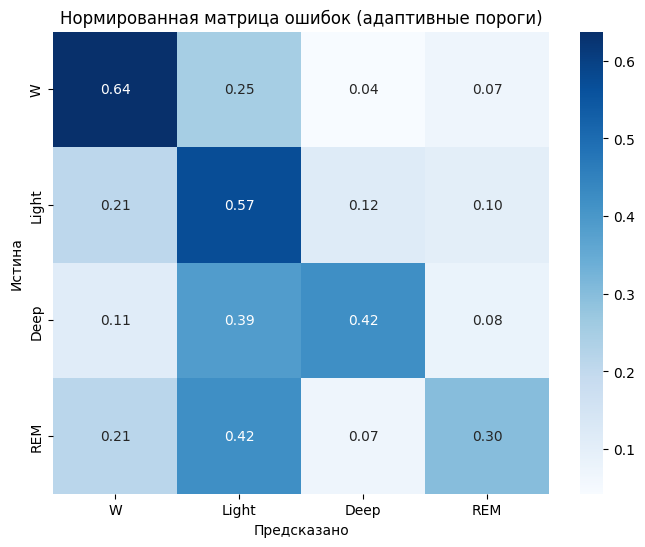

In [ ]:
# ---- 8. Оценка модели ----
print("\n" + "="*50)
print("ОЦЕНКА НА ТЕСТОВОМ НАБОРЕ")
print("="*50)

# Основные метрики
print(classification_report(y_test, y_pred, target_names=['W', 'Light', 'Deep', 'REM']))

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

# Матрица ошибок (нормированная)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=['W','Light','Deep','REM'],
            yticklabels=['W','Light','Deep','REM'], cmap='Blues')
plt.title('Нормированная матрица ошибок (адаптивные пороги)')
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.show()

In [ ]:
# ---- 9. Ошибка длительности фаз (в минутах) ----
def duration_error(y_true, y_pred, epoch_len_sec=30):
    """Вычисляет абсолютную и относительную ошибку суммарной длительности каждой фазы."""
    true_counts = np.bincount(y_true, minlength=4)
    pred_counts = np.bincount(y_pred, minlength=4)
    diff_min = (pred_counts - true_counts) * epoch_len_sec / 60.0
    rel_error = diff_min / (true_counts * epoch_len_sec / 60.0 + 1e-6) * 100
    return diff_min, rel_error

diff_min, rel_error = duration_error(y_test, y_pred)
classes = ['W', 'Light', 'Deep', 'REM']
print("\nОшибка длительности фаз (минуты, %):")
for i, cls in enumerate(classes):
    print(f"  {cls}: {diff_min[i]:+.1f} мин ({rel_error[i]:+.1f}%)")


Ошибка длительности фаз (минуты, %):
  W: -347.0 мин (-20.5%)
  Light: +285.5 мин (+33.7%)
  Deep: +21.5 мин (+7.4%)
  REM: +40.0 мин (+14.8%)



ECE (Expected Calibration Error): 0.0975


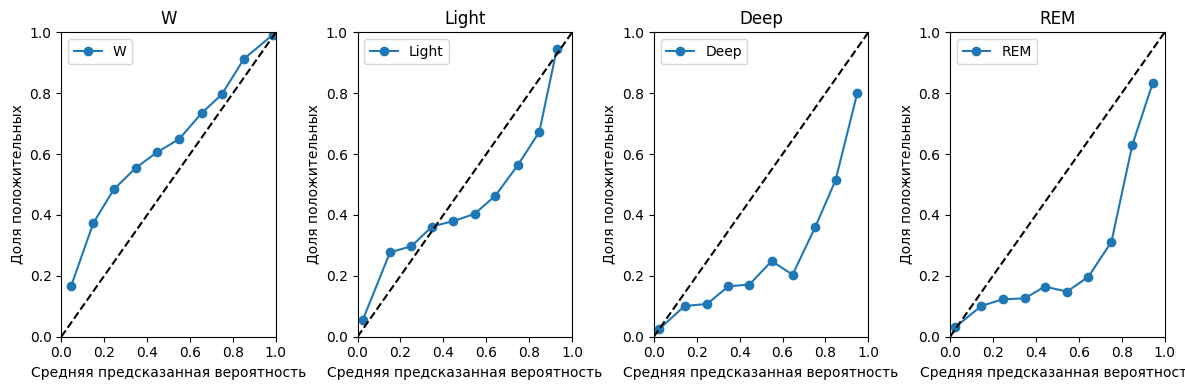

In [ ]:
# ---- 10. Калибровка вероятностей (ECE + Reliability Plot) ----
def calculate_ece(y_true, y_probs, n_bins=10):
    """Expected Calibration Error (ECE) с корректным вычислением весов бинов."""
    ece = 0.0
    for i in range(y_probs.shape[1]):
        prob_true = y_probs[:, i]
        y_bin = (y_true == i).astype(int)
        # Разбиваем на бины
        bin_edges = np.linspace(0, 1, n_bins+1)
        # Подсчёт количества в каждом бине и центров бинов
        counts, _ = np.histogram(prob_true, bins=bin_edges)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        # Доля положительных в каждом бине
        bin_positive = np.zeros(n_bins)
        for b in range(n_bins):
            mask = (prob_true >= bin_edges[b]) & (prob_true < bin_edges[b+1])
            if np.sum(mask) > 0:
                bin_positive[b] = np.mean(y_bin[mask])
        # Веса бинов (доля выборки)
        weights = counts / len(prob_true)
        ece += np.sum(np.abs(bin_positive - bin_centers) * weights)
    return ece / y_probs.shape[1]

ece = calculate_ece(y_test, probs_test)
print(f"\nECE (Expected Calibration Error): {ece:.4f}")

# Reliability plot для каждого класса (используем calibration_curve для визуализации)
from sklearn.calibration import calibration_curve
plt.figure(figsize=(12, 4))
for i, cls in enumerate(classes):
    plt.subplot(1, 4, i+1)
    prob_true = probs_test[:, i]
    y_bin = (y_test == i).astype(int)
    fraction_positive, mean_predicted = calibration_curve(y_bin, prob_true, n_bins=10, strategy='uniform')
    plt.plot(mean_predicted, fraction_positive, marker='o', label=cls)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Доля положительных')
    plt.title(f'{cls}')
    plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ---- 11. (Опционально) Ручная калибровка Platt scaling, если ECE > 0.05 ----
if ece > 0.05:
    print(f"\nECE = {ece:.4f} > 0.05, применяем ручную калибровку Platt (логистическая регрессия)...")
    
    from sklearn.linear_model import LogisticRegression
    
    # Получаем вероятности на валидации
    probs_val = best_clf.predict_proba(X_val)
    calibrators = []
    for i in range(n_classes):
        y_bin = (y_val == i).astype(int)
        X_cal = probs_val[:, i].reshape(-1, 1)
        lr = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
        lr.fit(X_cal, y_bin)
        calibrators.append(lr)
    
    # Применяем калибраторы к тестовым вероятностям
    cal_probs_test = np.zeros_like(probs_test)
    for i, lr in enumerate(calibrators):
        X_cal_test = probs_test[:, i].reshape(-1, 1)
        cal_probs_test[:, i] = lr.predict_proba(X_cal_test)[:, 1]
    
    # Нормализация, чтобы сумма вероятностей по классам была равна 1
    cal_probs_test = cal_probs_test / cal_probs_test.sum(axis=1, keepdims=True)
    
    # Применяем адаптивные пороги (подобранные ранее на валидации)
    preds_cal = []
    for probs in cal_probs_test:
        candidates = [i for i, p in enumerate(probs) if p >= thresholds[i]]
        if candidates:
            pred = max(candidates, key=lambda i: probs[i])
        else:
            pred = np.argmax(probs)
        preds_cal.append(pred)
    y_pred_cal = np.array(preds_cal)
    
    # Оценка после калибровки
    print("\nРезультаты после калибровки:")
    print(classification_report(y_test, y_pred_cal, target_names=classes))
    kappa_cal = cohen_kappa_score(y_test, y_pred_cal)
    print(f"Cohen's Kappa (калибр.): {kappa_cal:.3f}")
    
    diff_min_cal, rel_error_cal = duration_error(y_test, y_pred_cal)
    print("\nОшибка длительности после калибровки:")
    for i, cls in enumerate(classes):
        print(f"  {cls}: {diff_min_cal[i]:+.1f} мин ({rel_error_cal[i]:+.1f}%)")
    
    ece_cal = calculate_ece(y_test, cal_probs_test)
    print(f"\nECE до калибровки: {ece:.4f}")
    print(f"ECE после калибровки: {ece_cal:.4f}")
    if ece_cal > ece:
        print("⚠️  Внимание: ECE увеличился после калибровки. Возможно, калибровка не понадобилась.")
    else:
        print("✅ Калибровка улучшила ECE.")
else:
    print(f"\nECE = {ece:.4f} <= 0.05, калибровка не требуется.")


ECE = 0.0975 > 0.05, применяем ручную калибровку Platt (логистическая регрессия)...

Результаты после калибровки:
              precision    recall  f1-score   support

           W       0.68      0.86      0.76      3380
       Light       0.50      0.42      0.46      1695
        Deep       0.56      0.30      0.39       582
         REM       0.51      0.16      0.24       542

    accuracy                           0.63      6199
   macro avg       0.56      0.44      0.46      6199
weighted avg       0.60      0.63      0.60      6199

Cohen's Kappa (калибр.): 0.322

Ошибка длительности после калибровки:
  W: +457.5 мин (+27.1%)
  Light: -137.0 мин (-16.2%)
  Deep: -133.5 мин (-45.9%)
  REM: -187.0 мин (-69.0%)

ECE до калибровки: 0.0975
ECE после калибровки: 0.0343
✅ Калибровка улучшила ECE.


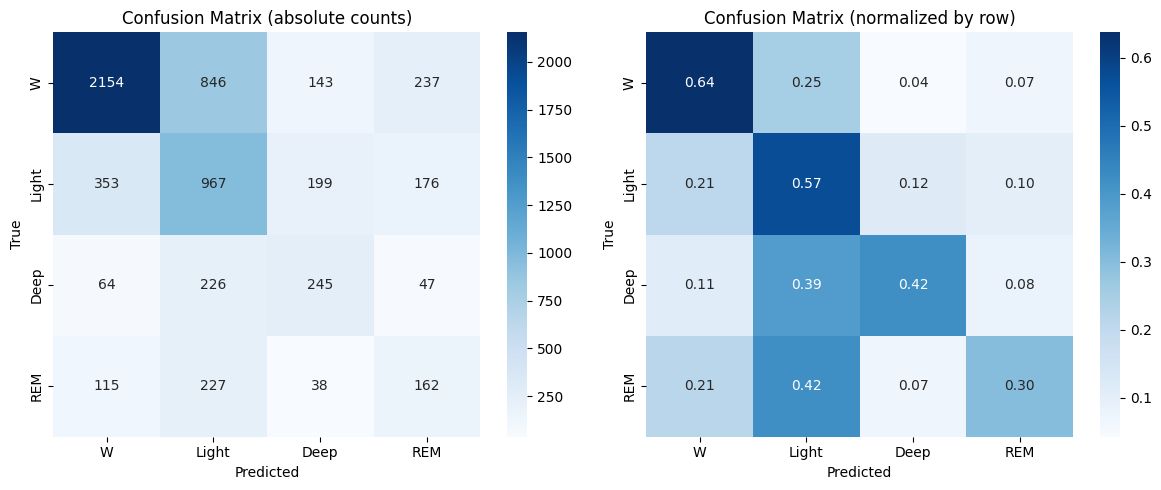

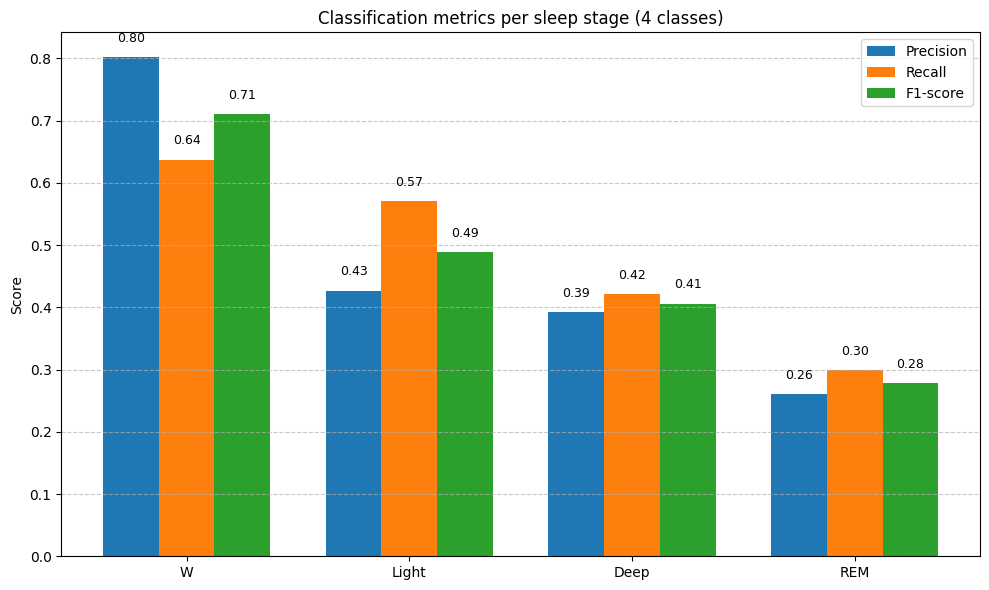

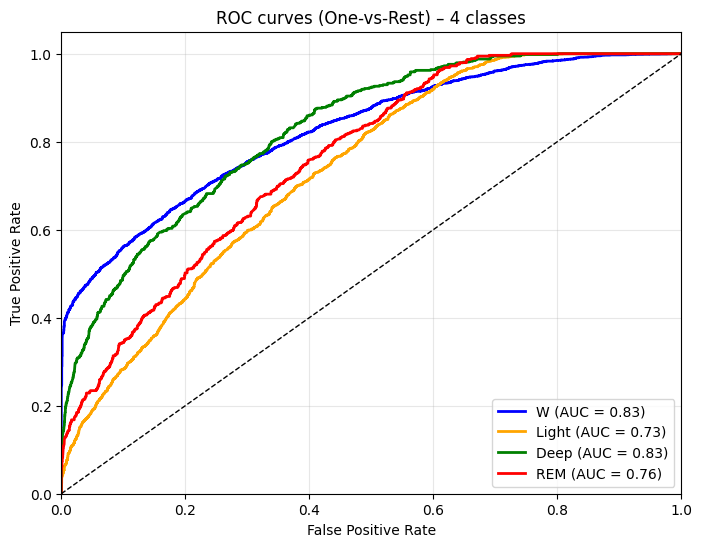

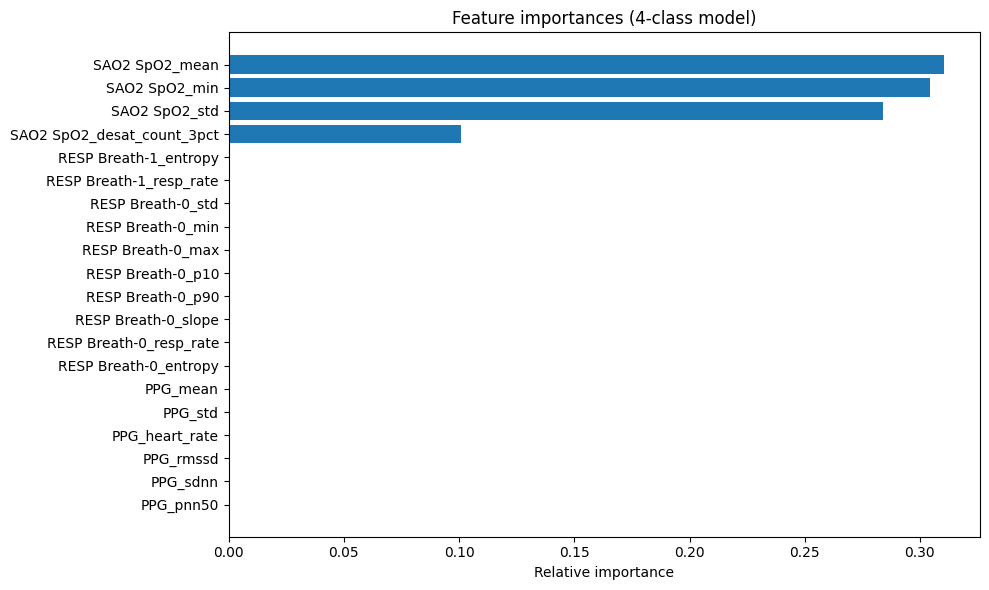

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import numpy as np

# Названия классов для 4 стадий
class_names = ['W', 'Light', 'Deep', 'REM']
n_classes = len(class_names)

# 1. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (absolute counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized by row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

# 2. Precision, Recall, F1 по классам
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1-score')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel('Score')
ax.set_title('Classification metrics per sleep stage (4 classes)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i, r + 0.02, f'{r:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 3. ROC-кривые (One-vs-Rest)
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Фиктивный скалер (XGBoost не требует масштабирования)
class IdentityScaler(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X

clf = random_search.best_estimator_
scaler = IdentityScaler()
pipeline = Pipeline([('scaler', scaler), ('classifier', clf)])

if hasattr(pipeline, 'predict_proba'):
    y_score = pipeline.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))
    colors = ['blue', 'orange', 'green', 'red']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curves (One-vs-Rest) – 4 classes')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Модель не поддерживает predict_proba.")

# 4. Важность признаков (RandomForest)
if hasattr(pipeline.named_steps['classifier'], 'feature_importances_'):
    importances = pipeline.named_steps['classifier'].feature_importances_
    feature_names = X_all.columns
    indices = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10, 6))
    plt.title('Feature importances (4-class model)')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Модель не предоставляет важность признаков.")

In [ ]:
# Оценка модели на каждом файле отдельно
from sklearn.metrics import accuracy_score, f1_score

# Получаем список успешно обработанных файлов
processed_files = list(file_counts.keys())

for fname, X_file, y_file in zip(processed_files, X_list, y_list):
    X_file_scaled = scaler.transform(X_file)
    y_pred_file = clf.predict(X_file_scaled)
    acc = accuracy_score(y_file, y_pred_file)
    f1 = f1_score(y_file, y_pred_file, average='weighted')
    print(f"{fname}: accuracy={acc:.3f}, f1={f1:.3f}")

111.edf: accuracy=0.738, f1=0.738
160.edf: accuracy=0.688, f1=0.698
196.edf: accuracy=0.724, f1=0.748
222.edf: accuracy=0.744, f1=0.751
233.edf: accuracy=0.770, f1=0.781
303.edf: accuracy=0.918, f1=0.925
304.edf: accuracy=0.553, f1=0.610
308.edf: accuracy=0.690, f1=0.704
310.edf: accuracy=0.691, f1=0.691
313.edf: accuracy=0.619, f1=0.651
314.edf: accuracy=0.587, f1=0.585
322.edf: accuracy=0.572, f1=0.577
325.edf: accuracy=0.375, f1=0.292
326.edf: accuracy=0.601, f1=0.675
334.edf: accuracy=0.578, f1=0.576
336.edf: accuracy=0.644, f1=0.681
337.edf: accuracy=0.669, f1=0.686
339.edf: accuracy=0.368, f1=0.402
341.edf: accuracy=0.793, f1=0.805
344.edf: accuracy=0.618, f1=0.630
345.edf: accuracy=0.647, f1=0.649
